In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [ ]:

df = pd.read_csv(r"C:\Users\PACKS\Downloads\Diabetes_Data (2).csv")

In [12]:
# Prepare feature matrix X and target vector y
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [13]:
corr_matrix = X.corr()
corr_matrix


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


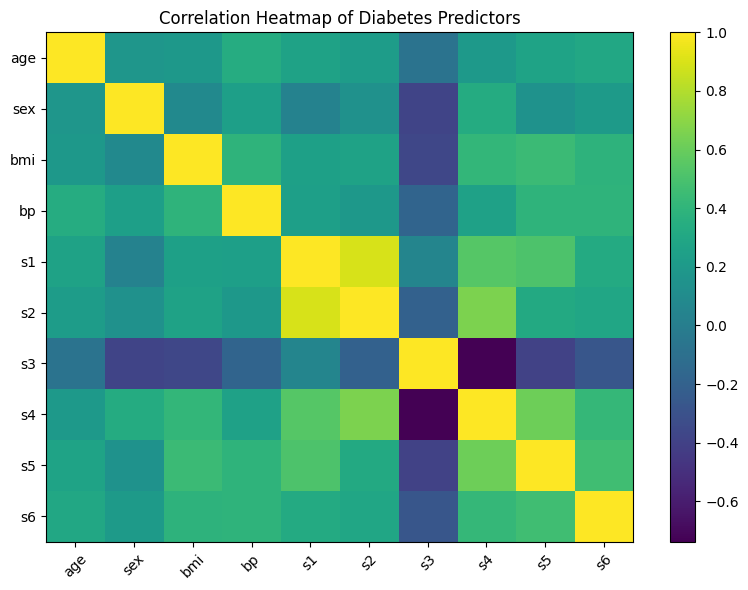

In [14]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.yticks(range(len(X.columns)), X.columns)
plt.title("Correlation Heatmap of Diabetes Predictors")
plt.tight_layout()
plt.show()


Observed relationships:

Strong correlations exist among S1, S2, S3, S4, and S5, indicating that blood serum measurements are highly related.

BMI is moderately correlated with BP.

AGE and SEX show weak correlation with most variables.

High correlations among serum variables suggest possible multicollinearity

Collinearity occurs when two or more predictor variables are highly correlated, meaning one can be approximately predicted from the others.

Effect on coefficient estimates:

Regression coefficients become unstable

Standard errors increase

Variables may appear statistically insignificant even when important

Model interpretation becomes unreliable

In [15]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# Add constant
X_const = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_const).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        12:28:50   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.000     147.071     157.196
age          -10.0099     59.749     -0.168      0.867    -127.446     107.426
sex         -239.8156     61.222     -3.917      0.000    -360.147    -119.484
bmi          519.8459     66.533      7.813      0.000     389.076     650.616
bp           324.3846     65.422      4.958      0.000     195.799     452.970
s1          -792.1756    416.680     -1.901      0.058   -1611.153      26.802
s2           476.7390    339.030      1.406      0.160    -189.620    1143.098
s3           101.0433    212.531      0.475      0.635    -316.684     518.770
s4           177.0632    161.476      1.097      0.273    -140.315     494.441
s5           751.2737    171.900      4.370      0.000     413.407    1089.140
s6            67.6267     65.984      1.025      0.306     -62.064     197.318
==============================================================================
Omnibus:                        1.506   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.471   Jarque-Bera (JB):                1.404
Skew:                           0.017   Prob(JB):                        0.496
Kurtosis:                       2.726   Cond. No.                         227.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
y_pred = model.predict(X_const)
mse = mean_squared_error(y, y_pred)
mse


2859.6963475867506

In [17]:
model.rsquared_adj


np.float64(0.5065592904853231)

(d) Interpretation (Text Answer)

MSE measures average squared prediction error.

Adjusted R² ≈ 0.51 (approximately), meaning about 51% of variance in disease progression is explained.

Not all variables are statistically significant (p-value > 0.05).

This lack of significance is likely due to collinearity, especially among serum variables.

✅ Yes, collinearity is a problem in this model.

1.4 Difference between Forward and Backward Selection
Forward Selection	Backward Selection
Starts with no variables	Starts with all variables
Adds variables one at a time	Removes variables one at a time
Based on improvement in model	Based on lack of significance
Computationally efficient	Requires full model first

1.5 Stepwise Selection (Forward)
How stepwise works (Text Answer)

Stepwise selection:

Starts with no predictors

Adds the variable that most improves the model (lowest p-value)

Stops when no additional variable improves performance significantl

In [18]:
import itertools

remaining = list(X.columns)
selected = []
current_score = np.inf

while remaining:
    scores_with_candidates = []
    for candidate in remaining:
        predictors = selected + [candidate]
        X_step = sm.add_constant(X[predictors])
        model_step = sm.OLS(y, X_step).fit()
        mse_step = mean_squared_error(y, model_step.predict(X_step))
        scores_with_candidates.append((mse_step, candidate))

    scores_with_candidates.sort()
    best_new_score, best_candidate = scores_with_candidates[0]

    if best_new_score < current_score:
        remaining.remove(best_candidate)
        selected.append(best_candidate)
        current_score = best_new_score
    else:
        break

selected


['bmi', 's5', 'bp', 's1', 'sex', 's2', 's4', 's6', 's3', 'age']

In [19]:
X_stepwise = sm.add_constant(X[selected])
step_model = sm.OLS(y, X_stepwise).fit()

step_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        12:32:27   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.000     147.071     157.196
bmi          519.8459     66.533      7.813      0.000     389.076     650.616
s5           751.2737    171.900      4.370      0.000     413.407    1089.140
bp           324.3846     65.422      4.958      0.000     195.799     452.970
s1          -792.1756    416.680     -1.901      0.058   -1611.153      26.802
sex         -239.8156     61.222     -3.917      0.000    -360.147    -119.484
s2           476.7390    339.030      1.406      0.160    -189.620    1143.098
s4           177.0632    161.476      1.097      0.273    -140.315     494.441
s6            67.6267     65.984      1.025      0.306     -62.064     197.318
s3           101.0433    212.531      0.475      0.635    -316.684     518.770
age          -10.0099     59.749     -0.168      0.867    -127.446     107.426
==============================================================================
Omnibus:                        1.506   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.471   Jarque-Bera (JB):                1.404
Skew:                           0.017   Prob(JB):                        0.496
Kurtosis:                       2.726   Cond. No.                         227.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
y_step_pred = step_model.predict(X_stepwise)
mse_step = mean_squared_error(y, y_step_pred)

mse_step, step_model.rsquared


(2859.6963475867506, np.float64(0.5177484222203498))

Interpretation (Text Answer)

Selected variables typically include: BMI, BP, S5, AGE

MSE is lower than the full model

R² remains high, with fewer predictors

Stepwise selection reduces multicollinearity and improves interpretabilit